# Data-driven retrieval: PyNNcml's two-step RNN on OpenMRG

A recurrent network that estimates rain rate and detects wet periods from
raw RSL/TSL (Habi & Messer 2020), trained against the nearest gauge.

The concise counterpart of `data_driven_tutorial.ipynb`, which is kept as
the upstream tutorial. Model, loss, windowing, training and evaluation live
in `src/rnn_retrieval.py`; figures in `src/plots.py`; PyNNcml workarounds
(NumPy 2, the local OpenMRG archive) in `src/pynncml_compat.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from core import viz_style as vs
import plots

vs.use_style()
from rnn_retrieval import (TrainConfig, openmrg_dataset, build_model, train,
                           predict, detection_scores, estimation_scores)

## Data

Ten days of OpenMRG, links within 2 km of a gauge, 80/20 split by link
(seeded). Rain is rare: the loss weights wet samples by an exponential fitted
to the gauge record.

`n_epochs=40` keeps this notebook to ~8 minutes on a CPU; the upstream
tutorial trains for 200 (`TrainConfig()`).

213 links, 10.2% of gauge samples wet


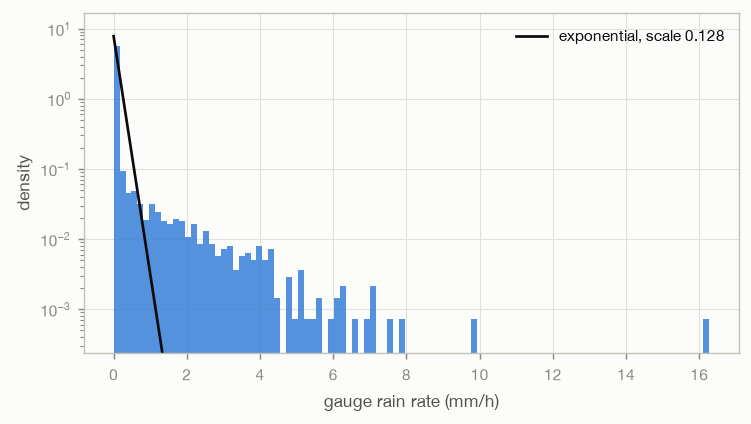

In [2]:
cfg = TrainConfig(n_epochs=40)
train_loader, val_loader, stats = openmrg_dataset(slice("2015-06-01", "2015-06-10"), cfg)
print(f"{len(stats['dataset'])} links, {stats['wet_fraction']:.1%} of gauge samples wet")
plots.rain_distribution(stats["rain"], stats["exp_fit"]);

## Train

Loss `λ·L_est + L_det`: rain-weighted MSE plus binary cross-entropy for
detection, with λ set so both start equal.

The exponential above is fitted to all gauge samples, 90% of them zero, so it
decays far faster than the wet tail; the loss weight
`1 - 0.9·exp(-r/0.128)` is already ~1 above 0.5 mm/h. That is the upstream
design, kept here.

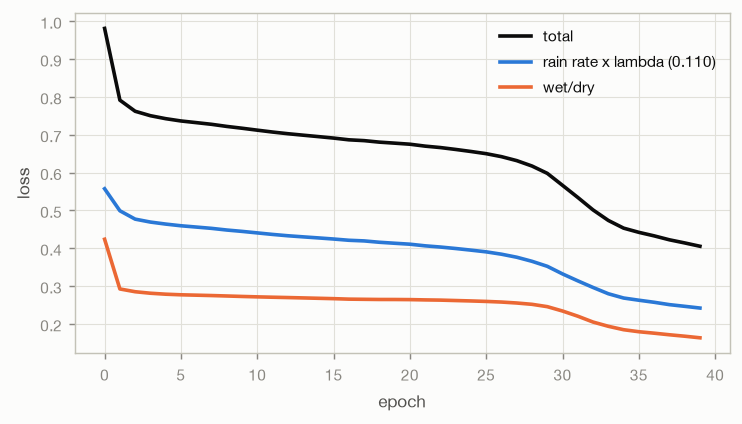

In [3]:
model = build_model(cfg, train_loader)
history = train(model, train_loader, cfg, stats["exp_gamma"], progress=False)
plots.training_curves(history);

## Validate on held-out links

detection  accuracy 95.1%  F1 0.667
estimation bias +0.000 mm/h  RMSE 0.416 mm/h


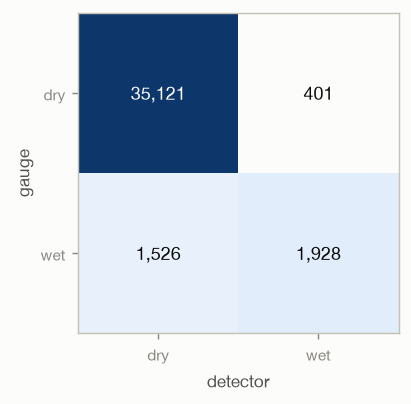

In [4]:
result = predict(model, val_loader, cfg)
det = detection_scores(result["ref"], result["detection"])
est = estimation_scores(result["ref"], result["rain_hat"])
print(f"detection  accuracy {det['accuracy']:.1%}  F1 {det['f1']:.3f}")
print(f"estimation bias {est['bias']:+.3f} mm/h  RMSE {est['rmse']:.3f} mm/h")
plots.confusion(det["confusion"]);

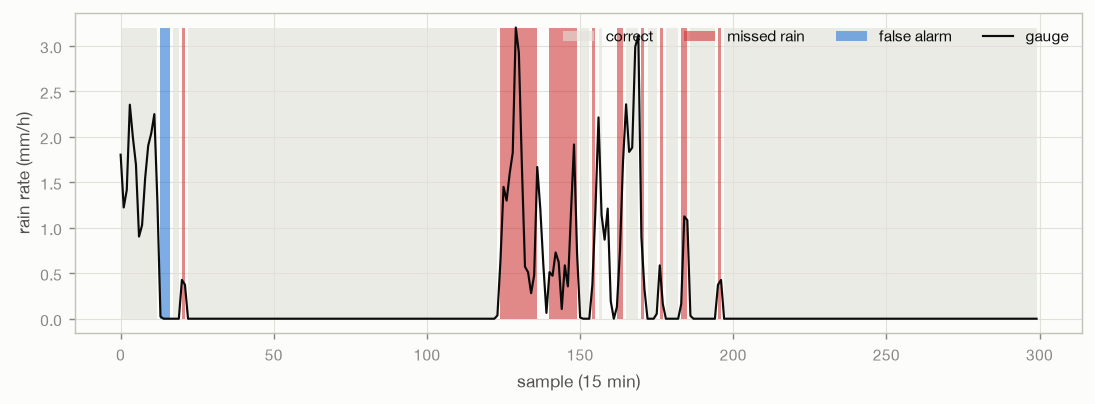

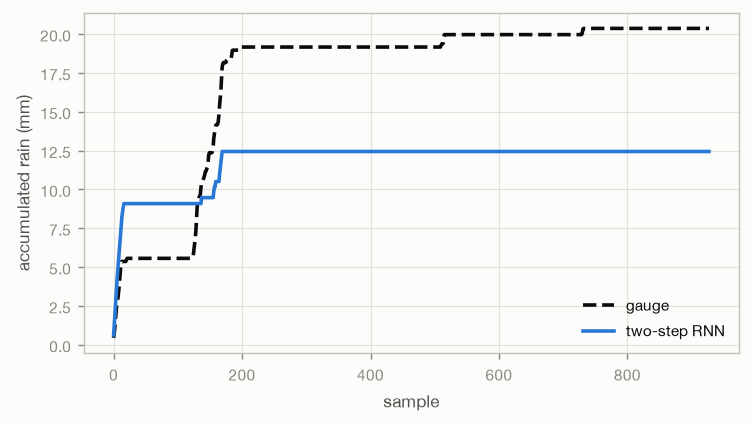

In [5]:
plots.detection_timeline(result["ref"], result["detection"], link=0);
plots.accumulation({"gauge": result["ref"][0], "two-step RNN": result["rain_hat"][0]});

Accuracy alone flatters a detector when ~90% of samples are dry - calling
everything dry scores ~90%. F1 and the missed-rain / false-alarm shading are
the numbers to watch.